# Data Visualization

# Online Retail Analytics

### Objective

This notebook presents key business insights through professional visualizations.
The charts are based on the cleaned dataset and the findings from the Exploratory Data Analysis (EDA).

### Goals

- Visualize sales performance
- Explore customer behavior
- Analyze product performance
- Compare geographic performance
- Communicate business insights effectively

In [27]:
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt

import plotly.express as px

In [28]:
DATA_PATH = Path("../data/processed/cleaned_online_retail.csv")

df = pd.read_csv(DATA_PATH)

In [29]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.6
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom,59.5
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,30.6
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom,45.0


In [5]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["TotalPrice"] = df["Quantity"] * df["Price"]

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour
df["Weekday"] = df["InvoiceDate"].dt.day_name()

In [6]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalPrice', 'Year', 'Month', 'Day',
       'Hour', 'Weekday'],
      dtype='str')

# Monthly Revenue Trend

## Business Question

How does total revenue change from month to month?

This visualization helps identify seasonality,
growth opportunities, and periods of weak sales.

In [7]:
monthly_revenue = (
    df.groupby("Month")["TotalPrice"]
      .sum()
      .reset_index()
)

monthly_revenue

,Month,TotalPrice
0,1,1123903.982
1,2,950643.876
2,3,1291060.231
3,4,1060356.333
4,5,1275188.530
5,6,1296417.180
6,7,1188699.071
7,8,1246275.640
8,9,1779704.153
9,10,2068754.460


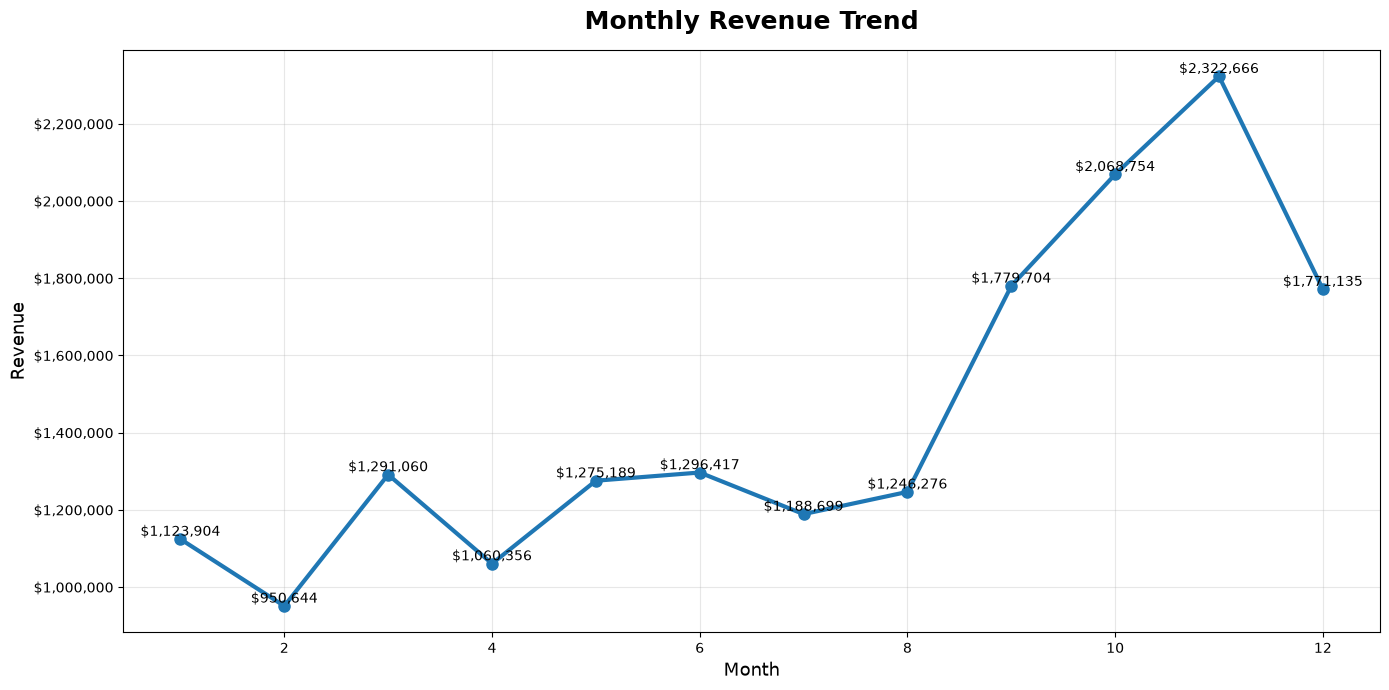

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    monthly_revenue["Month"],
    monthly_revenue["TotalPrice"],
    marker="o",
    linewidth=3,
    markersize=8
)

for x, y in zip(
    monthly_revenue["Month"],
    monthly_revenue["TotalPrice"]
):
    ax.text(
        x,
        y,
        f"${y:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

ax.set_title(
    "Monthly Revenue Trend",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Month", fontsize=13)
ax.set_ylabel("Revenue", fontsize=13)

ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

- Revenue is not evenly distributed across the year.
- Peak months indicate periods of strong customer demand.
- Lower-performing months may represent opportunities for targeted marketing campaigns or promotions.

# Revenue by Country

## Business Question

Which countries generate the highest revenue?

This analysis identifies the company's strongest markets and highlights
countries that contribute the most to overall revenue.

In [9]:
country_revenue = (
    df.groupby("Country")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

country_revenue

,Country,TotalPrice
0,United Kingdom,1.438923e+07
1,EIRE,6.165705e+05
2,Netherlands,5.540381e+05
3,Germany,4.250197e+05
4,France,3.487690e+05
5,Australia,1.692835e+05
6,Spain,1.083325e+05
7,Switzerland,1.000619e+05
8,Sweden,9.151582e+04
9,Denmark,6.858069e+04


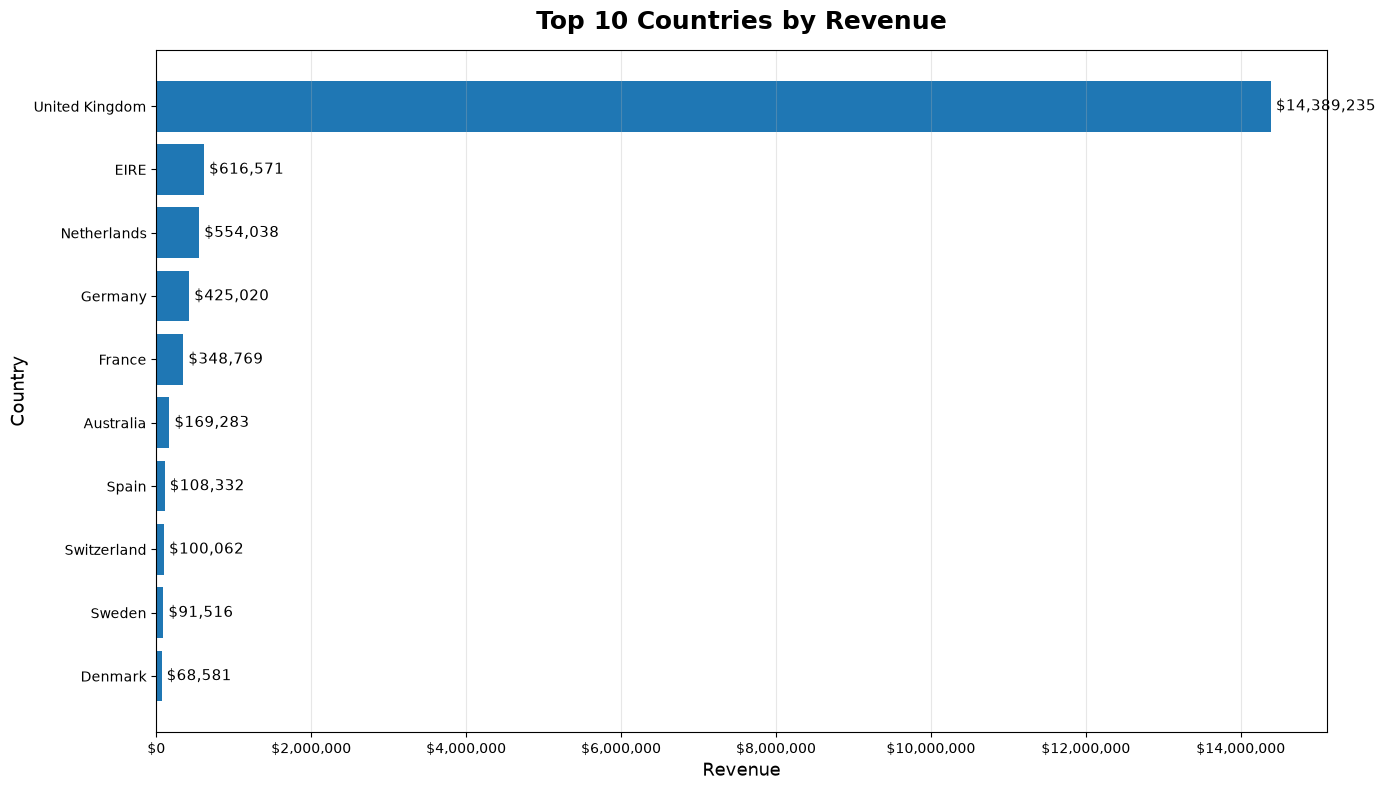

In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(
    country_revenue["Country"],
    country_revenue["TotalPrice"]
)

ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()

    ax.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f" ${width:,.0f}",
        va="center",
        fontsize=11
    )

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

ax.set_title(
    "Top 10 Countries by Revenue",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Revenue", fontsize=13)
ax.set_ylabel("Country", fontsize=13)

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

- The company generates most of its revenue from a small number of countries.
- The United Kingdom is expected to dominate revenue, indicating it is the primary market.
- International markets contribute additional revenue and may offer expansion opportunities.

# Revenue by Weekday

## Business Question

Which day of the week generates the highest revenue?

Understanding weekday sales patterns helps businesses optimize staffing,
marketing campaigns, and promotional activities.

In [11]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalPrice', 'Year', 'Month', 'Day',
       'Hour', 'Weekday'],
      dtype='str')

In [12]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_revenue = (
    df.groupby("Weekday")["TotalPrice"]
      .sum()
      .reindex(weekday_order)
      .reset_index()
)

weekday_revenue

,Weekday,TotalPrice
0,Monday,2778201.566
1,Tuesday,3322830.142
2,Wednesday,3021043.853
3,Thursday,3745783.432
4,Friday,2728473.173
5,Saturday,9803.050
6,Sunday,1768669.052


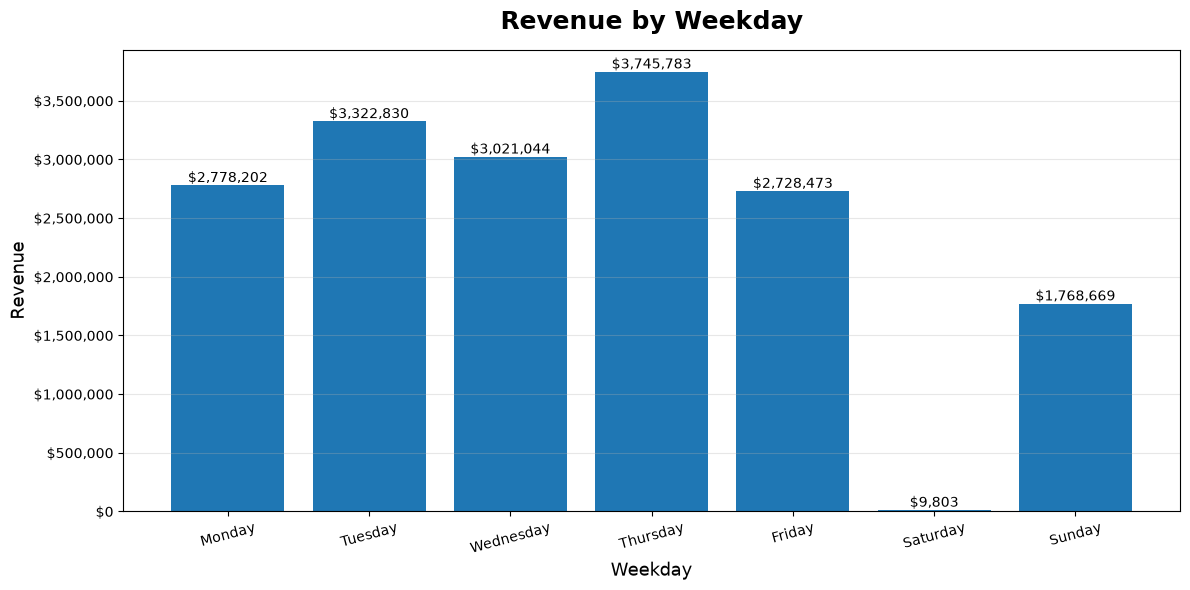

In [13]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    weekday_revenue["Weekday"],
    weekday_revenue["TotalPrice"]
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

ax.set_title(
    "Revenue by Weekday",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Weekday", fontsize=13)
ax.set_ylabel("Revenue", fontsize=13)

plt.xticks(rotation=15)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

- Revenue varies across the days of the week, indicating differences in customer purchasing behavior.
- Peak weekdays may be ideal for launching promotions or ensuring adequate inventory and staffing.
- Lower-performing days provide opportunities for targeted marketing campaigns to increase sales.

# Top 10 Customers by Revenue

## Business Question

Who are the highest-value customers?

Identifying the top customers helps businesses understand who contributes the
most revenue and supports customer retention strategies.

In [14]:
top_customers = (
    df.groupby("Customer ID")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_customers

,Customer ID,TotalPrice
0,18102.0,580987.04
1,14646.0,528602.52
2,14156.0,313437.62
3,14911.0,291420.81
4,17450.0,244784.25
5,13694.0,195640.69
6,17511.0,172132.87
7,16446.0,168472.50
8,16684.0,147142.77
9,12415.0,144458.37


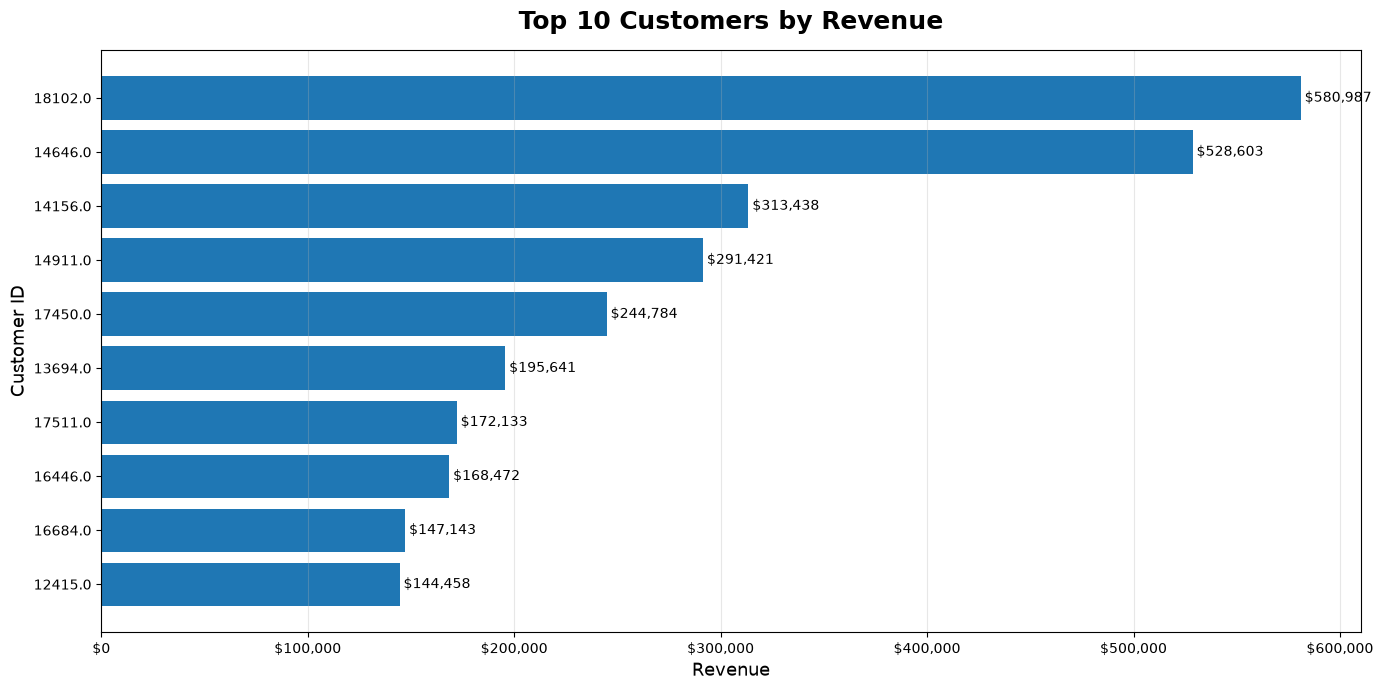

In [15]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(
    top_customers["Customer ID"].astype(str),
    top_customers["TotalPrice"]
)

ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()

    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" ${width:,.0f}",
        va="center",
        fontsize=10
    )

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

ax.set_title(
    "Top 10 Customers by Revenue",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Revenue", fontsize=13)
ax.set_ylabel("Customer ID", fontsize=13)

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

- A small group of customers contributes a significant share of total revenue.
- These high-value customers should be prioritized through loyalty programs,
  personalized offers, and retention strategies.
- Losing even a few of these customers could have a noticeable impact on revenue.

# Customer Spending Distribution

## Business Question

How is customer spending distributed?

This visualization helps determine whether revenue is generated evenly across
customers or concentrated among a smaller group of high-value customers.

In [16]:
customer_spending = (
    df.groupby("Customer ID")["TotalPrice"]
      .sum()
      .reset_index()
)

customer_spending.head()

,Customer ID,TotalPrice
0,12346.0,77556.46
1,12347.0,4921.53
2,12348.0,2019.40
3,12349.0,4428.69
4,12350.0,334.40


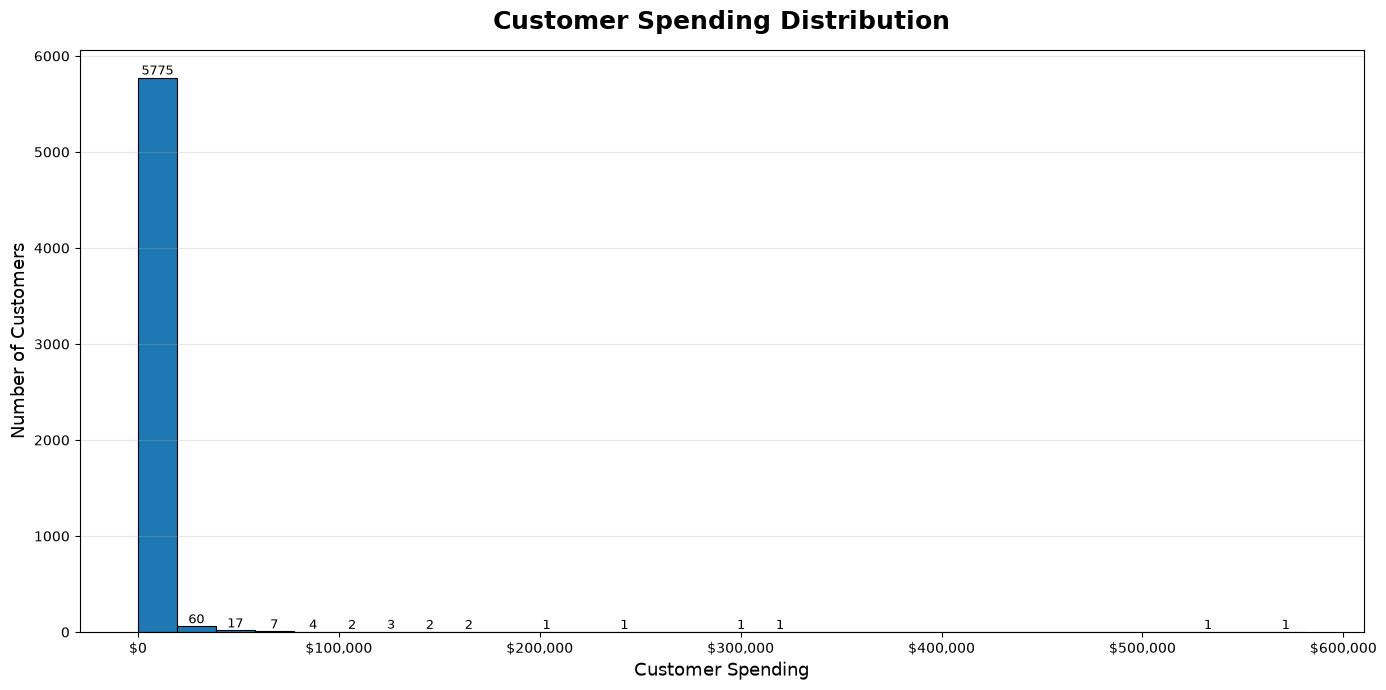

In [17]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(14, 7))

counts, bins, patches = ax.hist(
    customer_spending["TotalPrice"],
    bins=30,
    edgecolor="black",
    linewidth=0.8
)

for count, left, right in zip(counts, bins[:-1], bins[1:]):
    if count > 0:
        ax.text(
            (left + right) / 2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

ax.set_title(
    "Customer Spending Distribution",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Customer Spending", fontsize=13)
ax.set_ylabel("Number of Customers", fontsize=13)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Business Insight

- Most customers fall within the lower spending ranges.
- A relatively small number of customers account for very high spending.
- This pattern suggests that the business could benefit from customer segmentation and loyalty programs focused on high-value customers.

# Top 10 Products by Revenue

## Business Question

Which products generate the highest revenue?

This visualization identifies the company's best-performing products,
helping support inventory planning, pricing strategies, and marketing decisions.

In [18]:
top_products = (
    df.groupby("Description", as_index=False)["TotalPrice"]
      .sum()
      .sort_values("TotalPrice", ascending=False)
      .head(10)
)

top_products

,Description,TotalPrice
3769,REGENCY CAKESTAND 3 TIER,277656.25
5047,WHITE HANGING HEART T-LIGHT HOLDER,247048.01
3129,"PAPER CRAFT , LITTLE BIRDIE",168469.60
2860,Manual,151777.67
2392,JUMBO BAG RED RETROSPOT,134307.44
3547,POSTAGE,124648.04
292,ASSORTED COLOUR BIRD ORNAMENT,124351.86
3155,PARTY BUNTING,103283.38
2695,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
3122,PAPER CHAIN KIT 50'S CHRISTMAS,76598.18


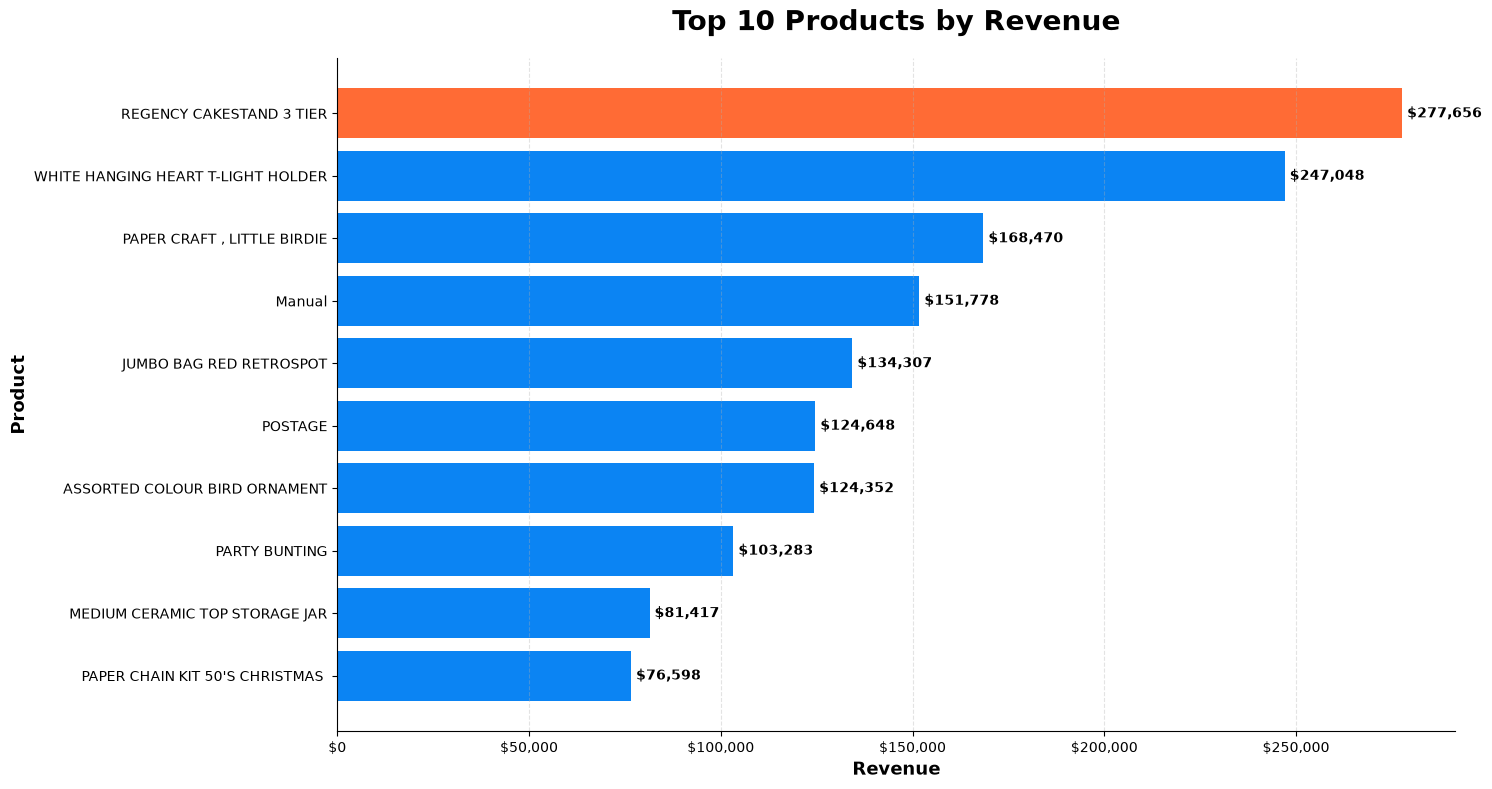

In [19]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(15, 8))

colors = ["#0B84F3"] * len(top_products)
colors[0] = "#FF6B35"      # Highlight top product

bars = ax.barh(
    top_products["Description"],
    top_products["TotalPrice"],
    color=colors
)

ax.invert_yaxis()

for bar in bars:
    value = bar.get_width()

    ax.text(
        value,
        bar.get_y() + bar.get_height()/2,
        f" ${value:,.0f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

ax.set_title(
    "Top 10 Products by Revenue",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Revenue",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Product",
    fontsize=13,
    fontweight="bold"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

### Business Insight

- The top-selling products contribute a disproportionately large share of total revenue.
- The highest-performing product has been highlighted to emphasize its business importance.
- These products should receive priority in inventory management, promotional campaigns, and demand forecasting.

# Top 10 Products by Quantity Sold

## Business Question

Which products are sold most frequently?

This visualization highlights the products with the highest sales volume,
helping the business optimize inventory planning, stock replenishment,
and demand forecasting.

In [20]:
top_quantity = (
    df.groupby("Description", as_index=False)["Quantity"]
      .sum()
      .sort_values("Quantity", ascending=False)
      .head(10)
)

top_quantity

,Description,Quantity
5168,WORLD WAR 2 GLIDERS ASSTD DESIGNS,105185
5047,WHITE HANGING HEART T-LIGHT HOLDER,91757
3129,"PAPER CRAFT , LITTLE BIRDIE",80995
292,ASSORTED COLOUR BIRD ORNAMENT,78234
2695,MEDIUM CERAMIC TOP STORAGE JAR,77916
2392,JUMBO BAG RED RETROSPOT,74224
751,BROCADE RING PURSE,70082
3065,PACK OF 60 PINK PAISLEY CAKE CASES,54592
157,60 TEATIME FAIRY CAKE CASES,52828
3067,PACK OF 72 RETRO SPOT CAKE CASES,45129


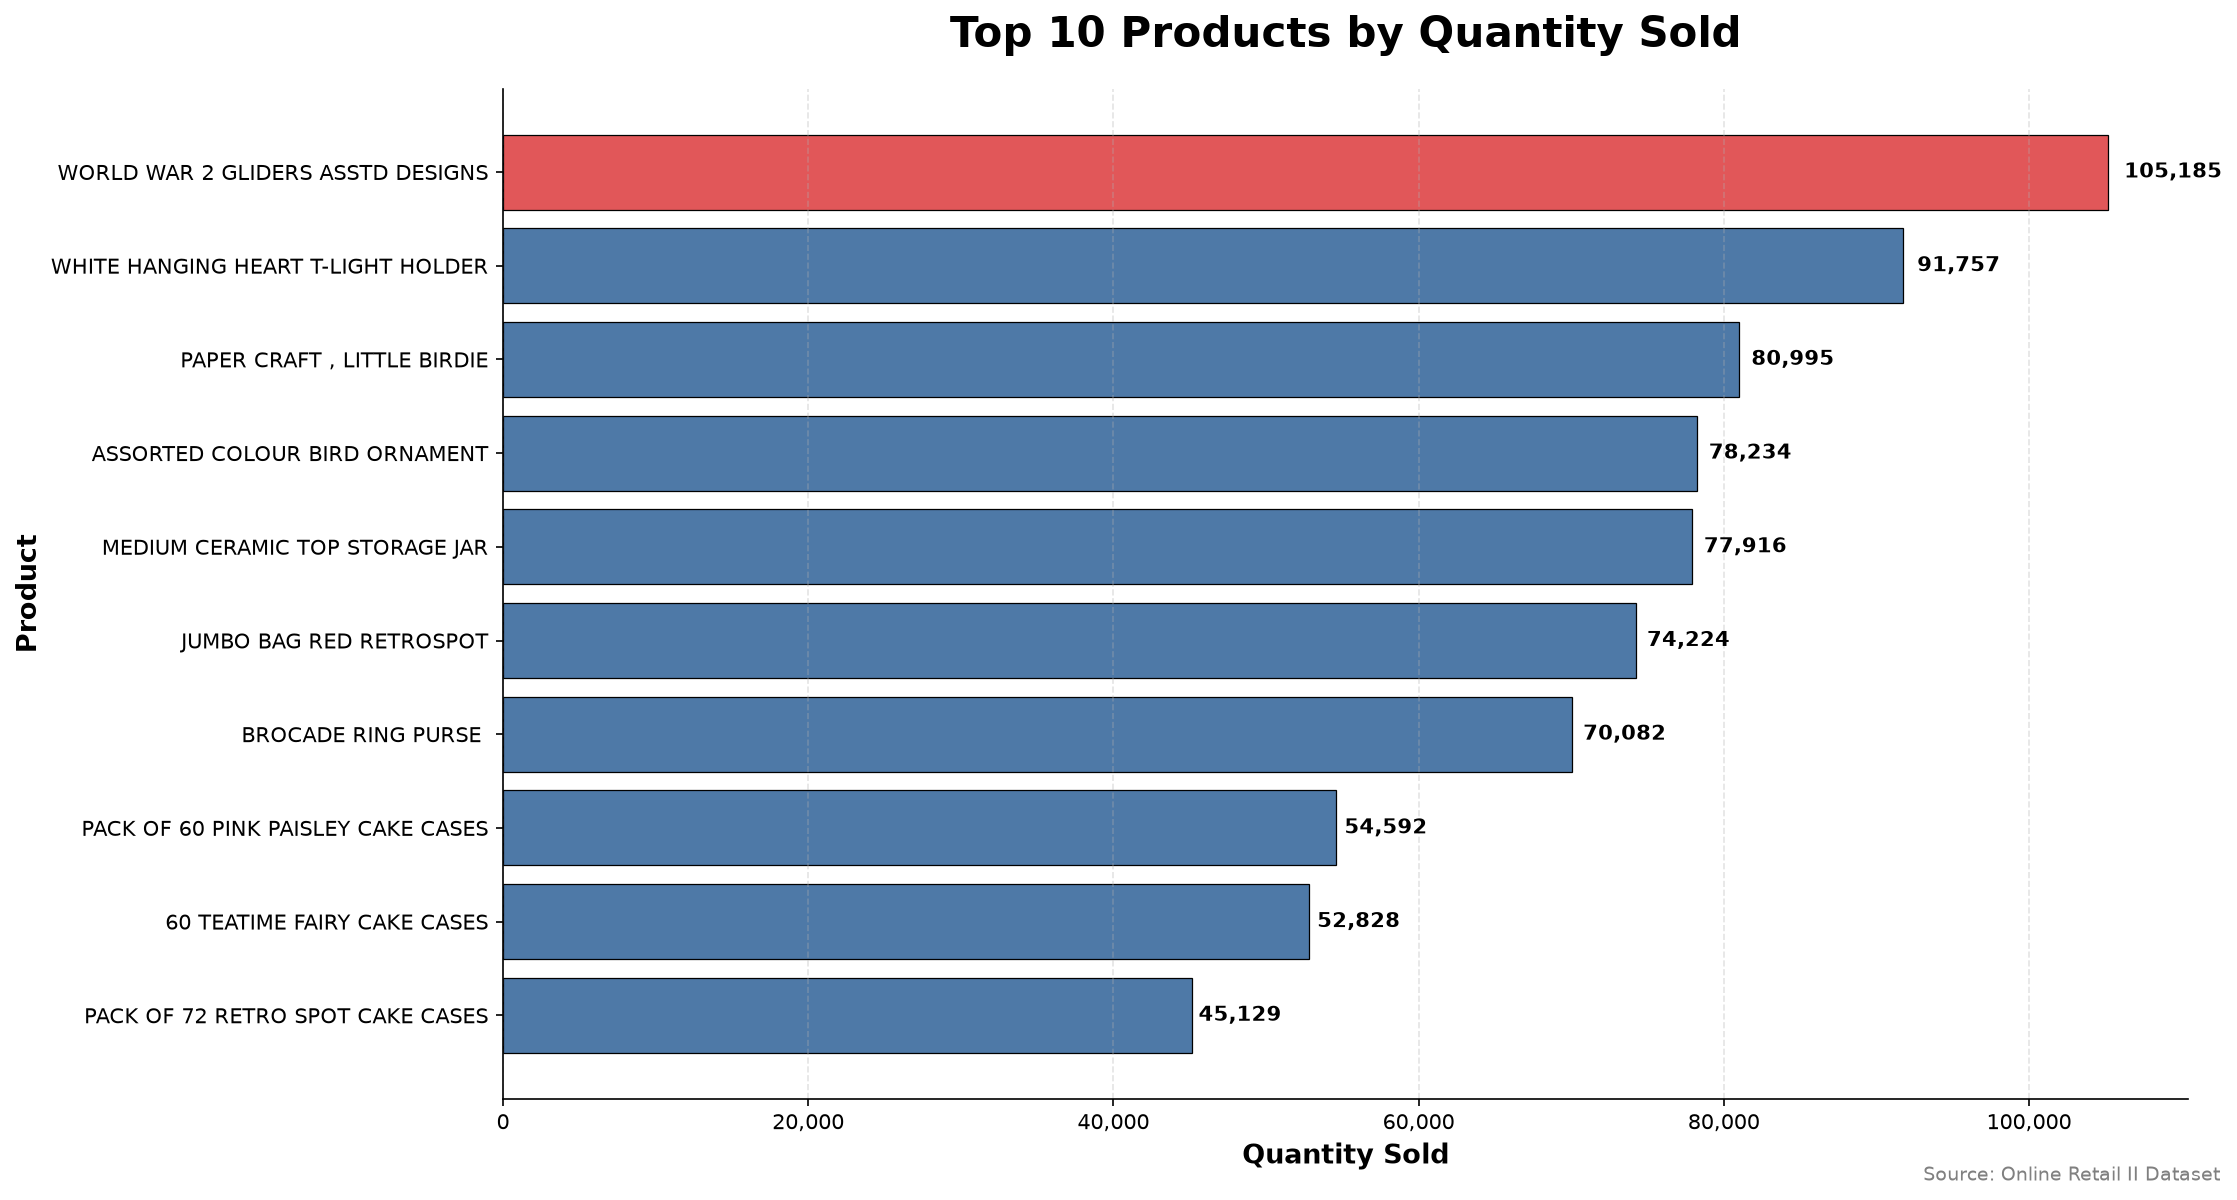

In [21]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(15, 8), dpi=150)

colors = ["#4E79A7"] * len(top_quantity)
colors[0] = "#E15759"

bars = ax.barh(
    top_quantity["Description"],
    top_quantity["Quantity"],
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

ax.invert_yaxis()

for bar in bars:
    value = bar.get_width()

    ax.text(
        value + (value * 0.01),
        bar.get_y() + bar.get_height()/2,
        f"{value:,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:,.0f}")
)

ax.set_title(
    "Top 10 Products by Quantity Sold",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Quantity Sold",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Product",
    fontsize=13,
    fontweight="bold"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.figtext(
    0.99,
    0.01,
    "Source: Online Retail II Dataset",
    ha="right",
    fontsize=9,
    color="gray"
)

plt.tight_layout()

plt.show()

### Business Insight

- The products with the highest sales volume are not always the products generating the highest revenue.
- High-volume products require careful inventory management to avoid stock shortages.
- Combining this analysis with revenue insights enables better pricing, promotion, and replenishment strategies.

# Top 10 Countries by Number of Orders

## Business Question

Which countries place the highest number of orders?

Understanding order volume by country helps identify the company's most active
markets and supports logistics, inventory allocation, and regional expansion strategies.

In [22]:
country_orders = (
    df.groupby("Country", as_index=False)["Invoice"]
      .nunique()
      .rename(columns={"Invoice": "Orders"})
      .sort_values("Orders", ascending=False)
      .head(10)
)

country_orders

,Country,Orders
38,United Kingdom,33541
14,Germany,789
13,France,614
10,EIRE,567
24,Netherlands,228
32,Spain,154
3,Belgium,149
33,Sweden,104
0,Australia,95
28,Portugal,93


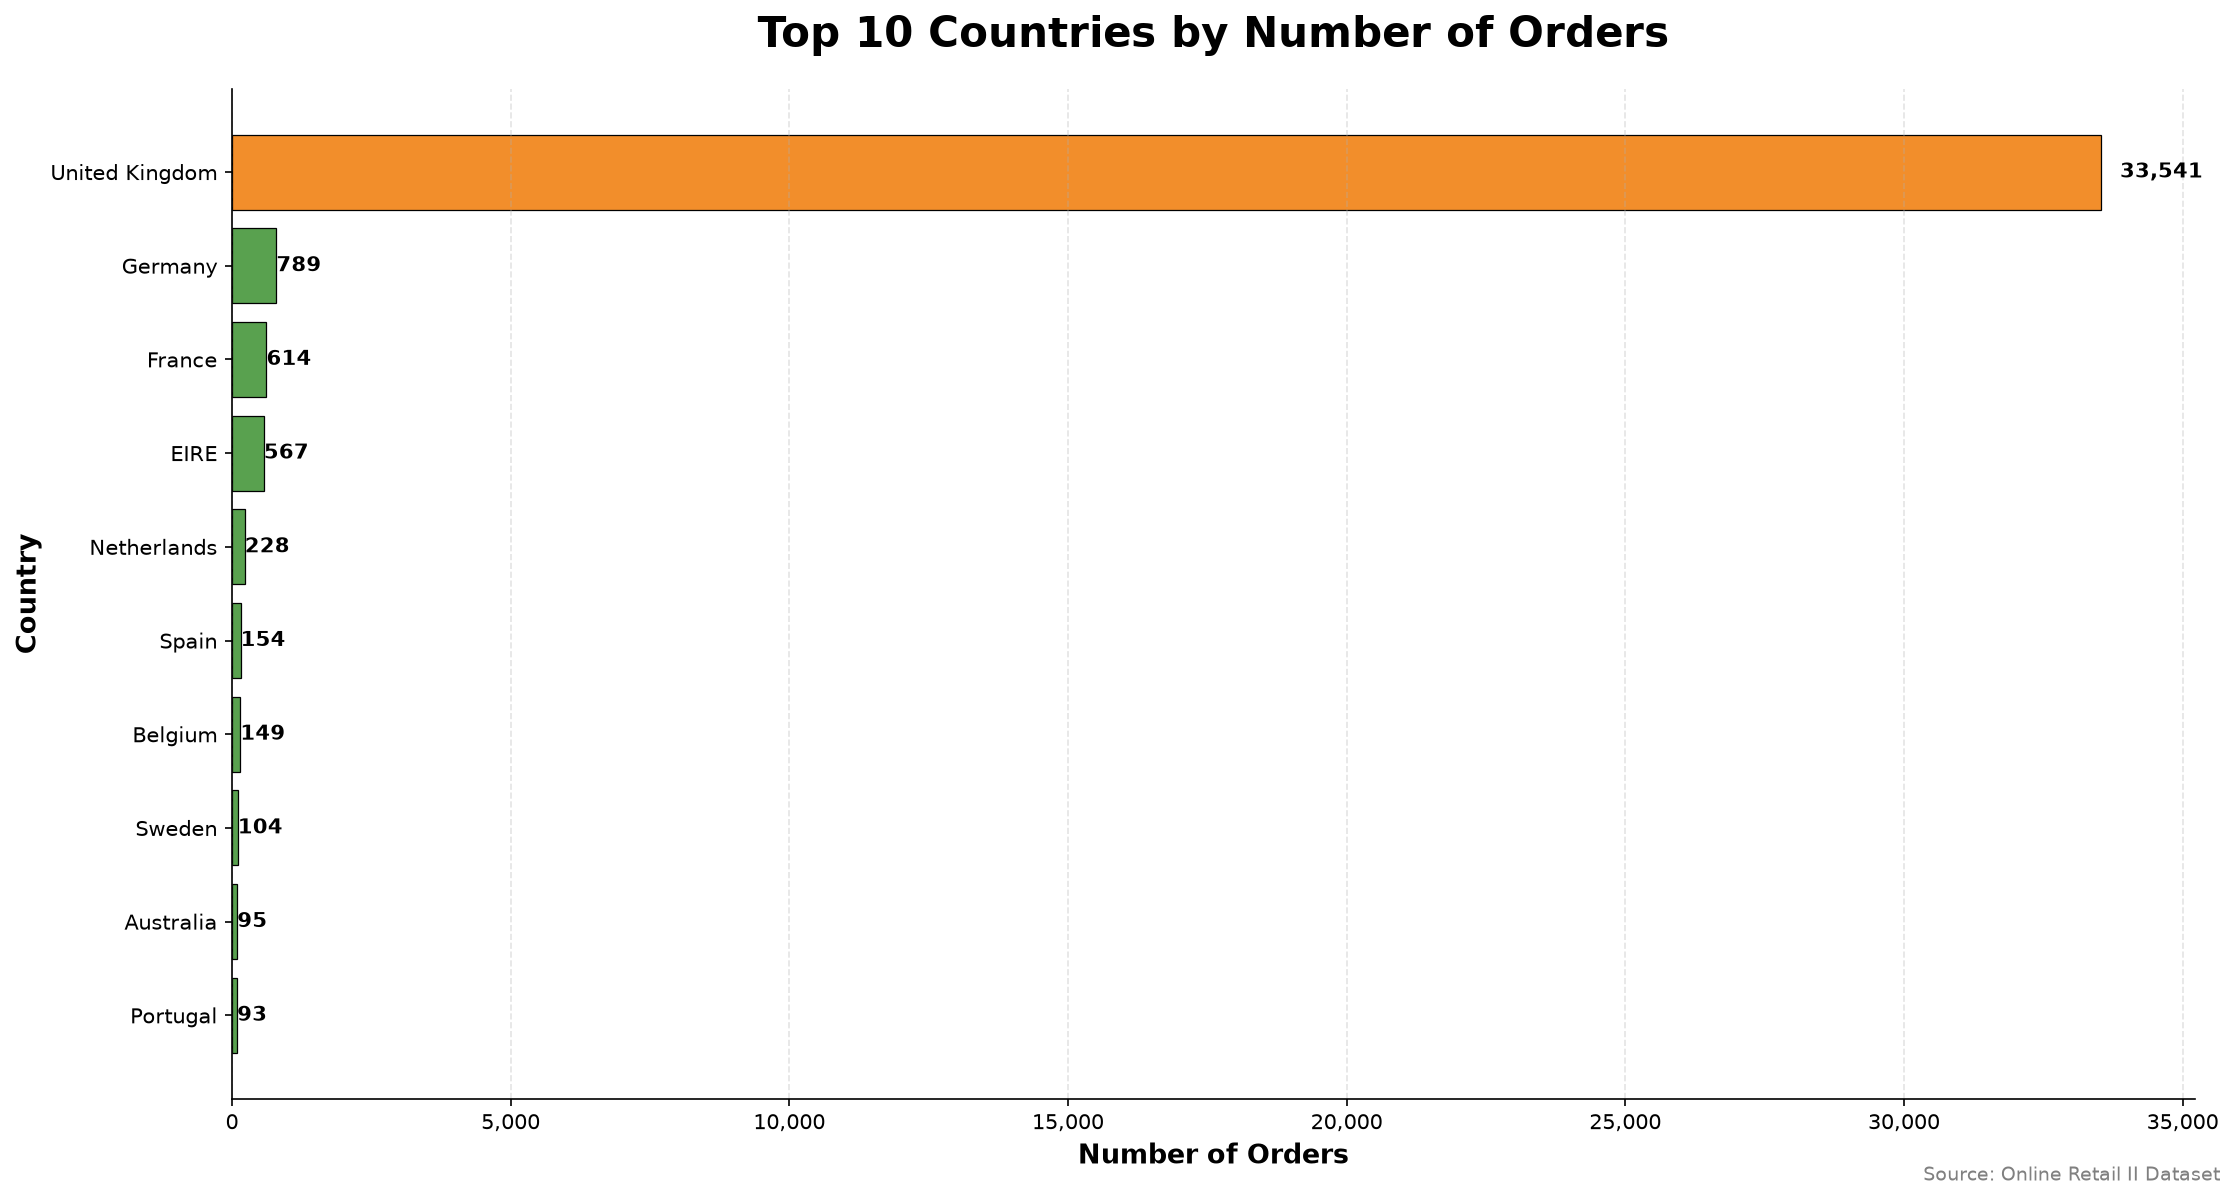

In [23]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(15, 8), dpi=150)

colors = ["#59A14F"] * len(country_orders)
colors[0] = "#F28E2B"

bars = ax.barh(
    country_orders["Country"],
    country_orders["Orders"],
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

ax.invert_yaxis()

for bar in bars:
    value = bar.get_width()

    ax.text(
        value + (value * 0.01),
        bar.get_y() + bar.get_height()/2,
        f"{int(value):,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)

ax.set_title(
    "Top 10 Countries by Number of Orders",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Number of Orders",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Country",
    fontsize=13,
    fontweight="bold"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.figtext(
    0.99,
    0.01,
    "Source: Online Retail II Dataset",
    ha="right",
    fontsize=9,
    color="gray"
)

plt.tight_layout()

plt.show()

### Business Insight

- Countries with the highest order volumes represent the company's most active customer bases.
- High order volume does not necessarily translate into the highest revenue, highlighting the importance of analyzing both metrics together.
- These markets are strong candidates for logistics optimization and customer retention initiatives.

# Order Value Distribution

## Business Question

How are customer order values distributed?

Understanding the distribution of order values helps identify purchasing patterns,
typical customer spending, and the presence of high-value orders.

In [24]:
order_values = (
    df.groupby("Invoice")["TotalPrice"]
      .sum()
      .reset_index()
)

order_values.head()

,Invoice,TotalPrice
0,489434,505.30
1,489435,145.80
2,489436,630.33
3,489437,310.75
4,489438,2286.24


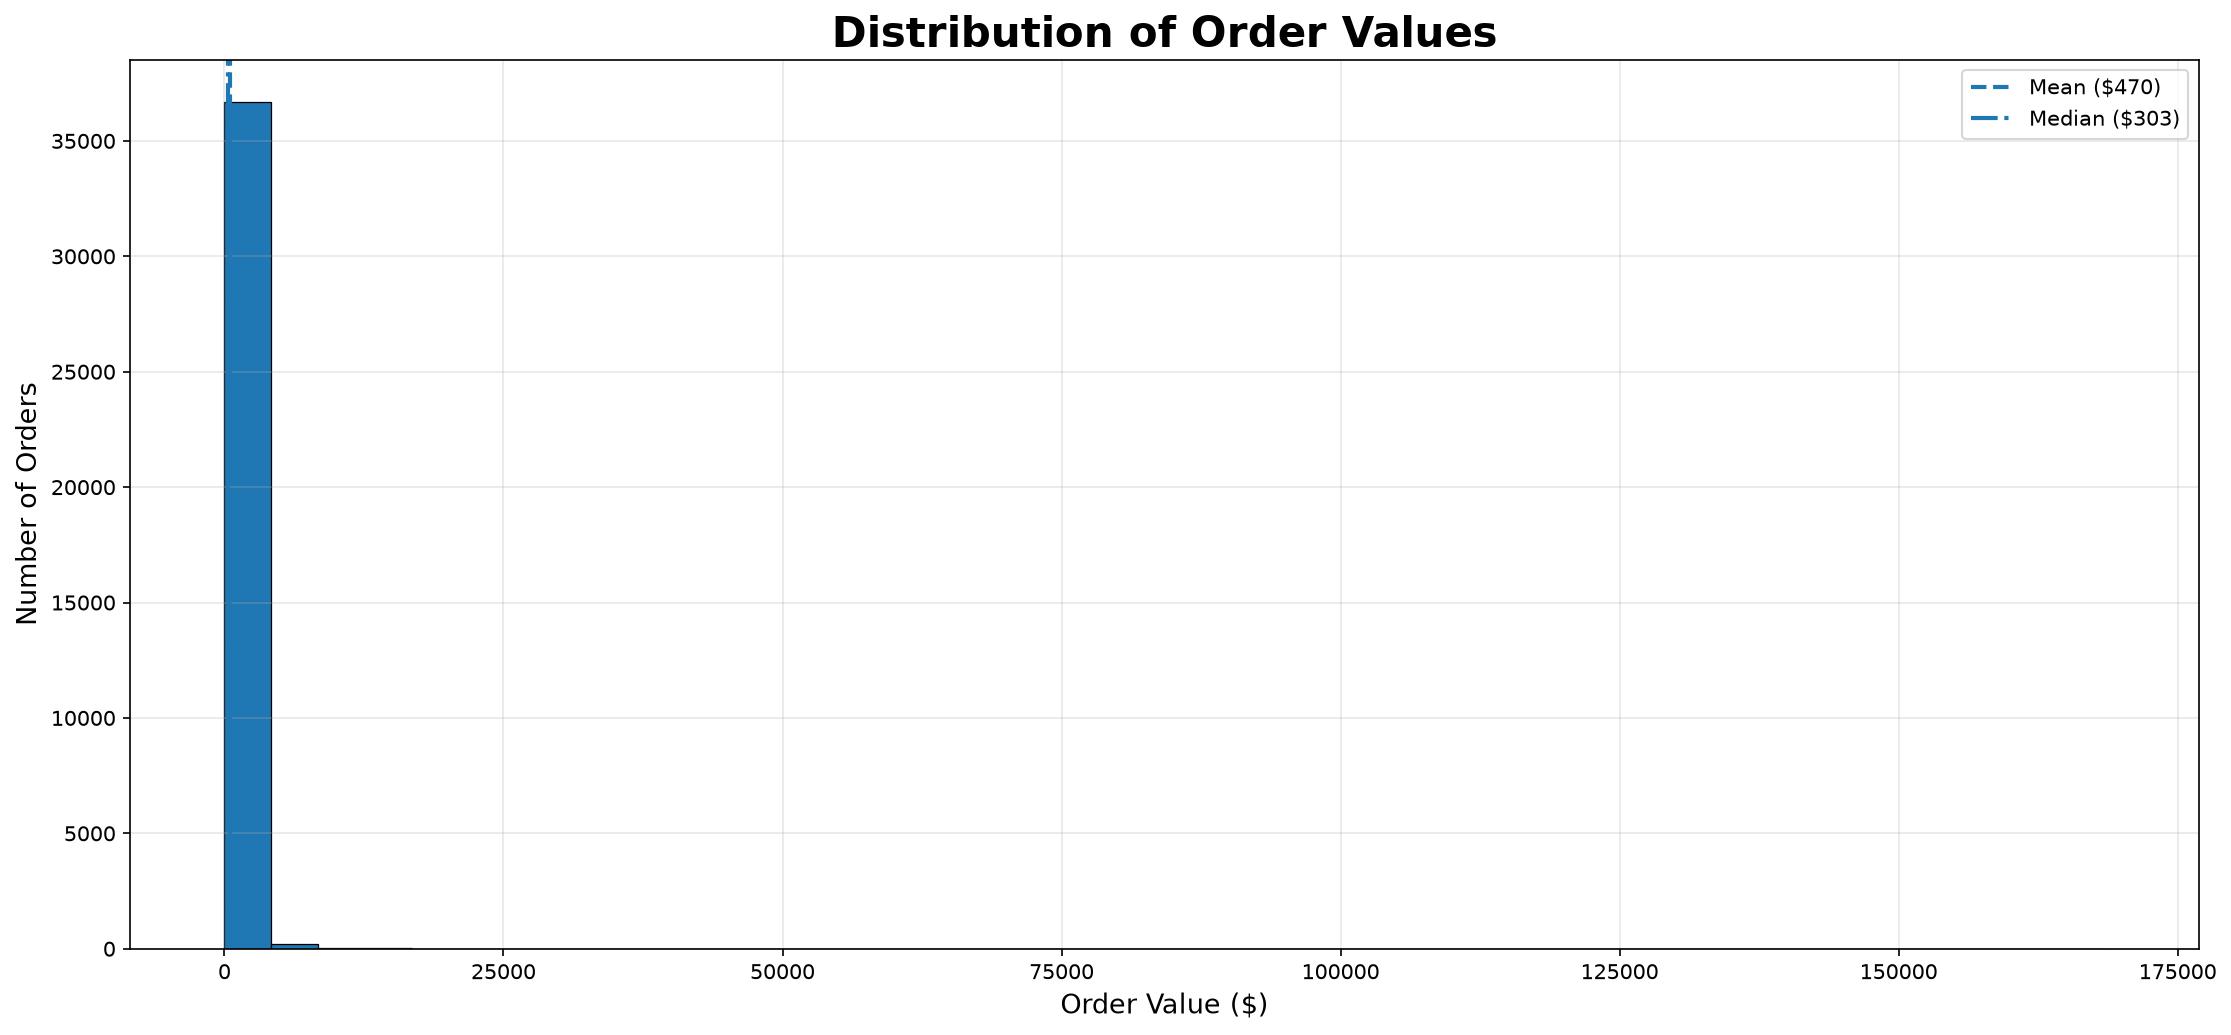

In [25]:
import matplotlib.pyplot as plt

mean_value = order_values["TotalPrice"].mean()
median_value = order_values["TotalPrice"].median()

fig, ax = plt.subplots(figsize=(15, 7), dpi=150)

ax.hist(
    order_values["TotalPrice"],
    bins=40,
    edgecolor="black",
    linewidth=0.6
)

ax.axvline(
    mean_value,
    linestyle="--",
    linewidth=2,
    label=f"Mean (${mean_value:,.0f})"
)

ax.axvline(
    median_value,
    linestyle="-.",
    linewidth=2,
    label=f"Median (${median_value:,.0f})"
)

ax.set_title(
    "Distribution of Order Values",
    fontsize=20,
    fontweight="bold"
)

ax.set_xlabel("Order Value ($)", fontsize=13)
ax.set_ylabel("Number of Orders", fontsize=13)

ax.grid(alpha=0.3)

ax.legend()

plt.tight_layout()

plt.show()

### Business Insight

- Most orders fall within a relatively low spending range.
- A smaller number of high-value orders increase the average order value.
- The gap between the mean and median suggests a right-skewed distribution, which is common in retail transactions.

# Executive Summary – Top 10 Countries by Revenue

## Business Question

Which countries contribute the most to the company's total revenue?

This visualization highlights the top-performing markets and provides a clear
comparison of revenue generated across the ten highest-performing countries.

In [26]:
top10_country_revenue = (
    df.groupby("Country", as_index=False)["TotalPrice"]
      .sum()
      .sort_values("TotalPrice", ascending=False)
      .head(10)
)

top10_country_revenue

,Country,TotalPrice
38,United Kingdom,1.438923e+07
10,EIRE,6.165705e+05
24,Netherlands,5.540381e+05
14,Germany,4.250197e+05
13,France,3.487690e+05
0,Australia,1.692835e+05
32,Spain,1.083325e+05
34,Switzerland,1.000619e+05
33,Sweden,9.151582e+04
9,Denmark,6.858069e+04


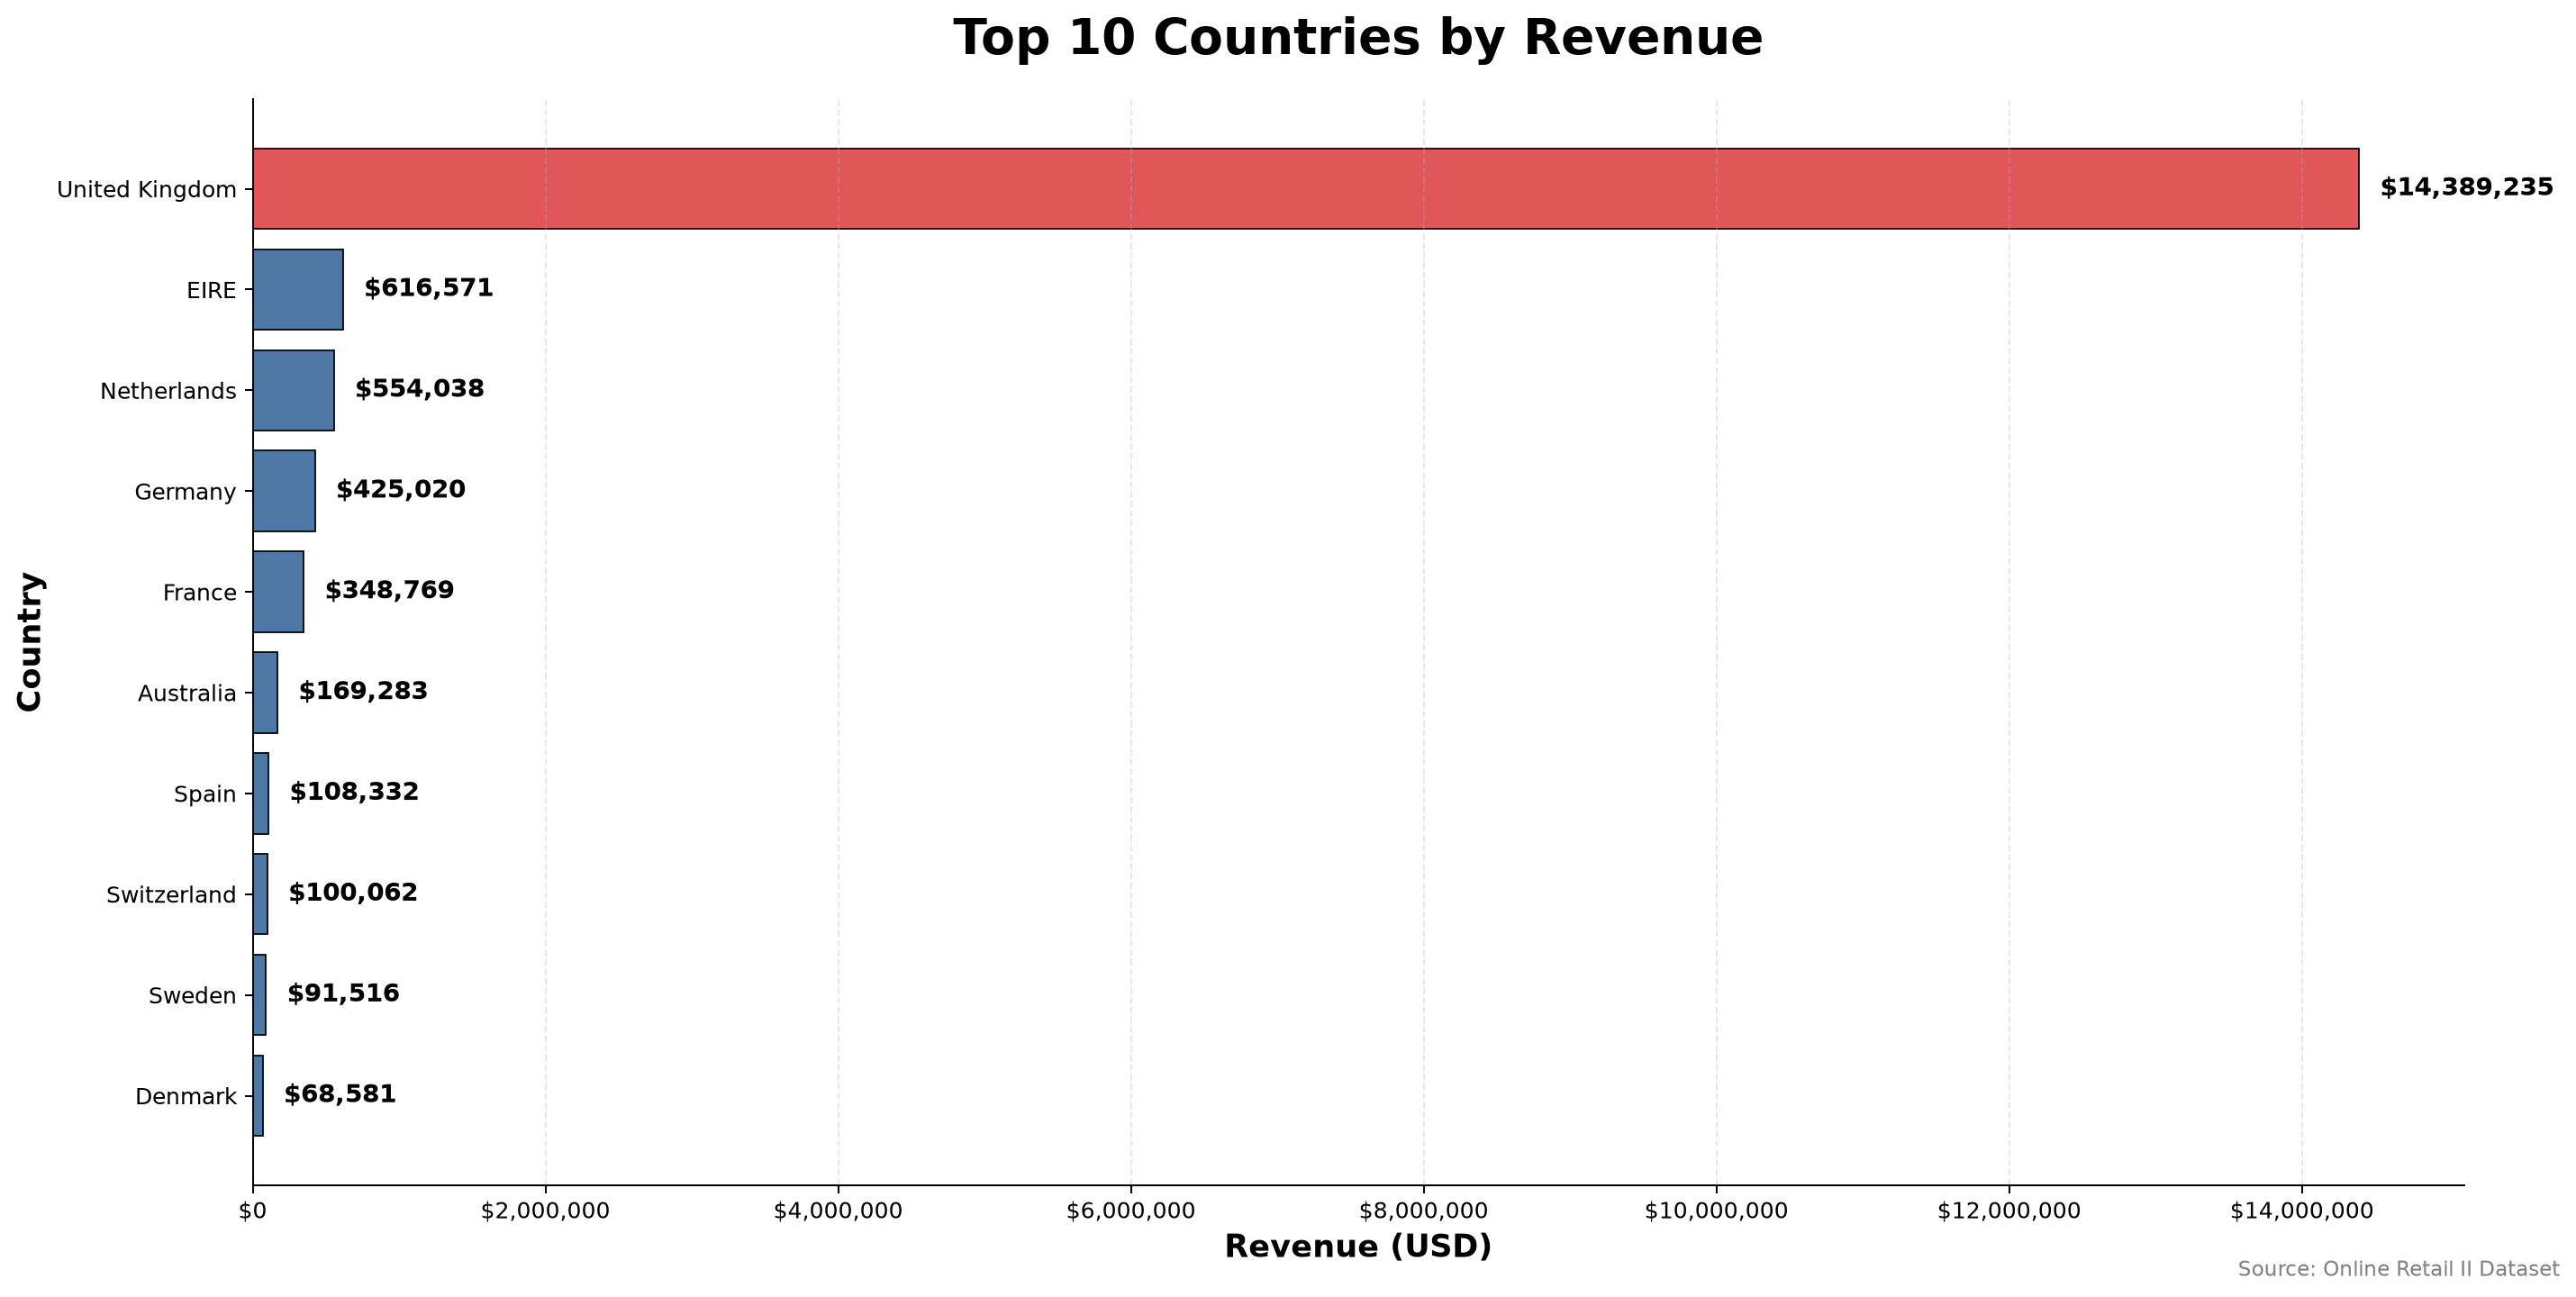

In [30]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(16, 8), dpi=180)

colors = ["#4E79A7"] * len(top10_country_revenue)
colors[0] = "#E15759"

bars = ax.barh(
    top10_country_revenue["Country"],
    top10_country_revenue["TotalPrice"],
    color=colors,
    edgecolor="black",
    linewidth=0.7
)

ax.invert_yaxis()

offset = top10_country_revenue["TotalPrice"].max() * 0.01

for bar in bars:
    value = bar.get_width()

    ax.text(
        value + offset,
        bar.get_y() + bar.get_height()/2,
        f"${value:,.0f}",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold"
    )

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

ax.set_title(
    "Top 10 Countries by Revenue",
    fontsize=22,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Revenue (USD)",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Country",
    fontsize=14,
    fontweight="bold"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.figtext(
    0.99,
    0.01,
    "Source: Online Retail II Dataset",
    ha="right",
    fontsize=9,
    color="gray"
)

plt.tight_layout()

plt.show()

### Business Insight

- Revenue is heavily concentrated in a small number of countries.
- The highlighted country represents the company's strongest international market.
- Businesses should prioritize customer retention, inventory planning, and marketing investments in these high-performing regions while identifying growth opportunities in emerging markets.